# CFMD Food Microbiome Analysis

**Data source:** CuratedFoodMetagenomicData (CFMD)
- `cFMD-main/cFMD-main/cFMD_metadata.tsv` — sample metadata with `category`, `sample_id`
- `cFMD-main/cFMD-main/cFMD_data/**/*_taxonomic_profiles.tsv` — per-dataset abundance matrices

**Tasks:**
1. Explore CFMD and analyze food microbial richness per category
2. Check species overlap between the top-2 richest categories

## Cell 1 — Setup and Metadata Loading

=== CFMD Metadata ===
Shape   : (3444, 32)
Columns : ['dataset_name', 'sample_id', 'macrocategory', 'category', 'type', 'subtype', 'commercial_name', 'fermented/non-fermented', 'country', 'sample_accession', 'run_accession', 'experiment_accession', 'study_accession', 'project_accession', 'database_origin', 'library_layout', 'sequencing_platform', 'DNA_extraction_kit', 'collection_date', 'n_of_bases', 'n_of_reads', 'min_read_len', 'median_read_len', 'mean_read_len', 'max_read_len', 'n_contigs', 'n_MAGs_MQ_prok', 'n_MAGs_HQ_prok', 'n_MAGs_MQ_euk', 'n_MAGs_HQ_euk', 'filtered', 'curator']

'category' — 15 unique values:
category
dairy                              2296
fermented_beverages                 435
fermented_meat                      157
meat                                119
fish                                 93
fermented_grains                     83
fermented_seeds                      65
fermented_fruits_and_vegetables      52
alcohol                              48
fruits_

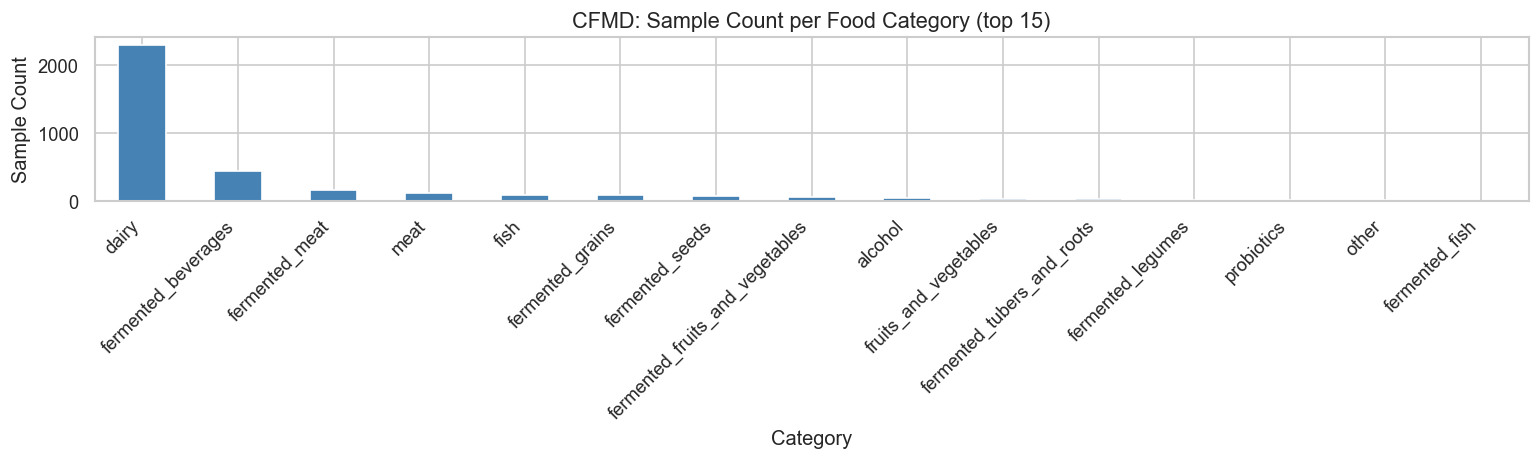

Plot saved → category_distribution.png

Macrocategory counts:
macrocategory
food    3444

Sequencing platform counts:
sequencing_platform
Illumina_NovaSeq_6000          1616
NextSeq_500                    1053
Illumina_MiSeq                  283
HiSeq X Ten                     119
Illumina_HiSeq_2500             102
Illumina_HiSeq_4000              75
NextSeq_550                      71
Illumina_HiSeq_2000              41
HiSeq_X_Ten                      20
Illumina_HiSeq_1500              15
Illumina_HiSeq_XTen              14
Illumina HiSeq 4000              13
Ion_Torrent_PGM                  10
Illumina NovaSeq 6000             4
Illumina MiSeq                    2
Illumina_Genome_Analyzer_II       2
Illumina_HiSeq_1000               2
Sequel;Illumina_MiSeq             1
Illumina HiSeq X                  1


In [ ]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# ── Load metadata ─────────────────────────────────────────────────────────────
metadata = pd.read_csv('./cFMD-main/cFMD-main/cFMD_metadata.tsv', sep='\t')

metadata.columns = metadata.columns.astype(str).str.strip()
metadata['sample_id'] = metadata['sample_id'].astype(str).str.strip()

print('=== CFMD Metadata ===')
print(f'Shape   : {metadata.shape}')
print(f'Columns : {metadata.columns.tolist()}')
print()

# ── EDA: category distribution ────────────────────────────────────────────────
cat_counts = metadata['category'].value_counts()
print(f"'category' — {cat_counts.shape[0]} unique values:")
print(cat_counts.to_string())

fig, ax = plt.subplots(figsize=(13, 4))
cat_counts.head(15).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('CFMD: Sample Count per Food Category (top 15)', fontsize=13)
ax.set_xlabel('Category')
ax.set_ylabel('Sample Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → category_distribution.png')

# ── EDA: macrocategory distribution ──────────────────────────────────────────
print()
print('Macrocategory counts:')
print(metadata['macrocategory'].value_counts().to_string())

# ── EDA: sequencing platform ──────────────────────────────────────────────────
print()
print('Sequencing platform counts:')
print(metadata['sequencing_platform'].value_counts().to_string())

## Cell 2 — Load Taxonomic Profiles and Merge with Metadata

Each `*_taxonomic_profiles.tsv` file is a wide matrix: rows = taxa, columns = samples.
Column names are formatted as `DatasetName__SampleAccession`.
We extract the accession part (after `__`) to match `sample_id` in the metadata.

In [ ]:
profile_files = glob.glob(
    './cFMD-main/cFMD-main/cFMD_data/**/*_taxonomic_profiles.tsv',
    recursive=True
)

print(f'Found {len(profile_files)} taxonomic profile files')

all_profiles = []
skipped = []

for path in profile_files:
    try:
        df = pd.read_csv(path, sep='\t')
        # First column is always the taxonomy column
        tax_col = df.columns[0]
        df = df.rename(columns={tax_col: '#taxonomy'})

        # Melt wide → long
        long = df.melt(
            id_vars=['#taxonomy'],
            var_name='sample_col',
            value_name='abundance'
        )

        # Column names: 'DatasetName__SampleAccession' → extract accession after '__'
        long['sample_id'] = long['sample_col'].str.split('__').str[-1]
        long = long.drop(columns=['sample_col'])
        all_profiles.append(long)

    except Exception as e:
        skipped.append((path, str(e)))

if skipped:
    print(f'\nSkipped {len(skipped)} files:')
    for p, e in skipped:
        print(f'  {p}: {e}')

# Combine all datasets
long_df = pd.concat(all_profiles, ignore_index=True)
long_df['sample_id'] = long_df['sample_id'].astype(str).str.strip()
long_df['abundance'] = pd.to_numeric(long_df['abundance'], errors='coerce').fillna(0)

print(f'\nCombined long-format shape : {long_df.shape}')
print(f'Unique sample IDs in profiles : {long_df["sample_id"].nunique()}')
print(f'Unique taxa in profiles       : {long_df["#taxonomy"].nunique()}')

# ── Merge with metadata ───────────────────────────────────────────────────────
merged = long_df.merge(
    metadata[['sample_id', 'category', 'macrocategory', 'country', 'fermented/non-fermented']],
    on='sample_id',
    how='left'
)

# Filter: keep only rows with positive abundance
merged_filtered = merged[merged['abundance'] > 0].copy()

print(f'\nRows after filtering (abundance > 0) : {len(merged_filtered):,}')
print(f'Unique taxa retained                 : {merged_filtered["#taxonomy"].nunique()}')
print(f'Missing category (unmatched samples) : {merged_filtered["category"].isna().sum():,}')
print(f'Categories present                   : {merged_filtered["category"].nunique()}')
print()
print('Sample category distribution:')
print(merged_filtered.dropna(subset=['category'])["category"].value_counts().to_string())

display(merged_filtered.head())

Found 85 taxonomic profile files

Combined long-format shape : (1614609, 3)
Unique sample IDs in profiles : 3392
Unique taxa in profiles       : 5057

Rows after filtering (abundance > 0) : 94,491
Unique taxa retained                 : 5051
Missing category (unmatched samples) : 0
Categories present                   : 15

Sample category distribution:
category
dairy                              57653
fermented_beverages                 7663
fermented_meat                      5649
meat                                4976
fish                                4558
fermented_seeds                     4537
fruits_and_vegetables               2883
fermented_fruits_and_vegetables     1637
fermented_tubers_and_roots          1465
fermented_grains                    1161
alcohol                              944
fermented_legumes                    936
other                                223
probiotics                           114
fermented_fish                        92


,#taxonomy,abundance,sample_id,category,macrocategory,country,fermented/non-fermented
0,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactob...,0.14109,SRR8742576,fermented_seeds,food,BRA,F
3,k__Bacteria|p__Pseudomonadota|c__Gammaproteoba...,0.10390,SRR8742576,fermented_seeds,food,BRA,F
7,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactob...,14.74891,SRR8742576,fermented_seeds,food,BRA,F
12,k__Bacteria|p__Firmicutes|c__Bacilli|o__Lactob...,0.33599,SRR8742576,fermented_seeds,food,BRA,F
20,k__Eukaryota|p__Ascomycota|c__Saccharomycetes|...,0.89747,SRR8742576,fermented_seeds,food,BRA,F


## Cell 3 — Task 1: Microbial Richness per Food Category

**Richness** = number of unique taxa with abundance > 0 per food category.

=== Microbial Richness per Food Category ===
                       category  microbial_richness
                          dairy                2967
                 fermented_meat                 854
          fruits_and_vegetables                 823
            fermented_beverages                 751
                fermented_seeds                 718
     fermented_tubers_and_roots                 699
fermented_fruits_and_vegetables                 529
                           fish                 490
                           meat                 380
              fermented_legumes                 368
               fermented_grains                 361
                        alcohol                 330
                          other                 158
                 fermented_fish                  44
                     probiotics                  36


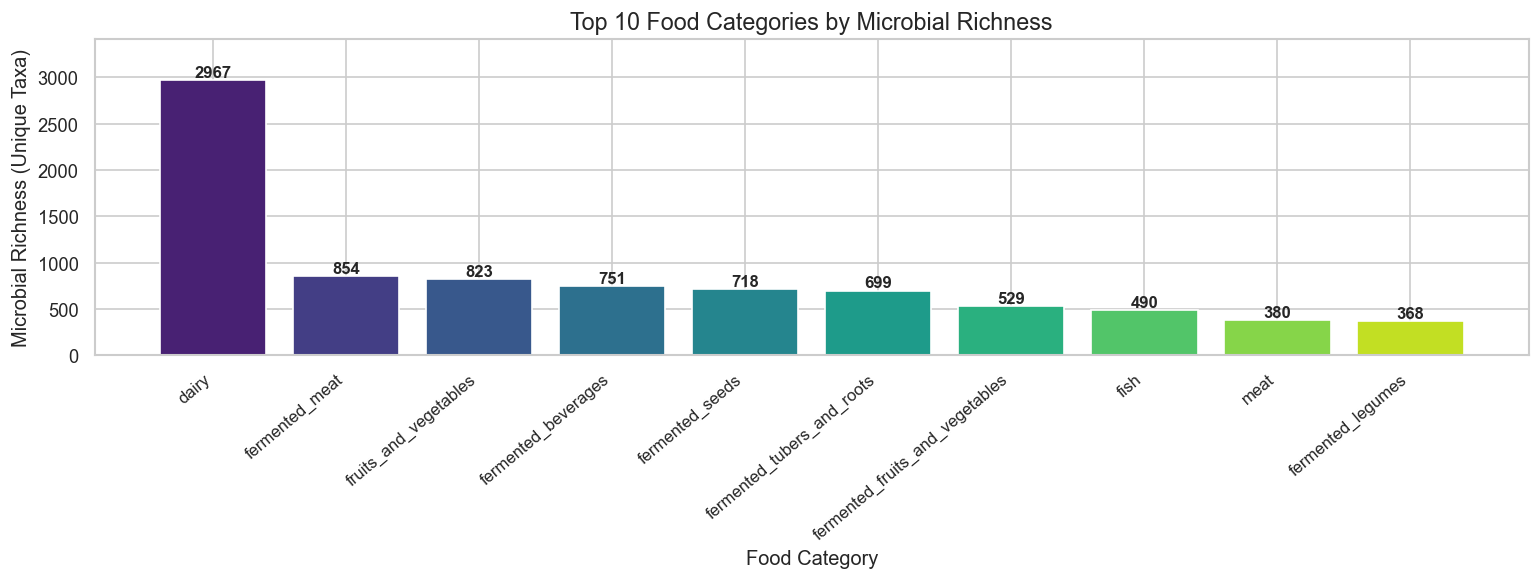

Plot saved → richness_by_category.png


In [16]:
# Guard: verify merge succeeded
if 'category' not in merged_filtered.columns or merged_filtered['category'].isna().all():
    raise RuntimeError('category data is missing — merge did not succeed. Fix Cell 2.')

richness = (
    merged_filtered
    .dropna(subset=['category'])
    .groupby('category')['#taxonomy']
    .nunique()
    .reset_index(name='microbial_richness')
    .sort_values('microbial_richness', ascending=False)
    .reset_index(drop=True)
)

print('=== Microbial Richness per Food Category ===')
print(richness.to_string(index=False))

# ── Bar chart: top 10 ─────────────────────────────────────────────────────────
top10   = richness.head(10)
palette = sns.color_palette('viridis', len(top10))

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(
    top10['category'],
    top10['microbial_richness'],
    color=palette,
    edgecolor='white'
)
for bar, val in zip(bars, top10['microbial_richness']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        str(int(val)),
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('Top 10 Food Categories by Microbial Richness', fontsize=14)
ax.set_xlabel('Food Category', fontsize=12)
ax.set_ylabel('Microbial Richness (Unique Taxa)', fontsize=12)
ax.set_ylim(0, top10['microbial_richness'].max() * 1.15)
plt.xticks(rotation=40, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig('richness_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → richness_by_category.png')

## Cell 4 — Task 2: Species Overlap between Top-2 Categories (Venn Diagram)

We compare the two richest food categories using a Venn diagram and the Jaccard similarity index.

Comparing: 'dairy'  vs  'fermented_meat'

Species unique to 'dairy'  : 2,346
Species unique to 'fermented_meat'  : 233
Shared species              : 621
Jaccard similarity index    : 0.1941

Top shared species (last taxonomic level):
  t__SGB257
  t__SGB203
  t__SGB282
  t__SGB39400
  t__SGB33761
  t__SGB23979
  t__SGB98684
  t__SGB86828
  t__SGB17183
  t__SGB17232
  t__SGB93302
  t__SGB98927
  t__SGB99001
  t__SGB99002
  t__SGB16645
  t__SGB98807
  t__SGB16638
  t__SGB98794
  t__SGB16639
  t__SGB88049
  ... and 601 more


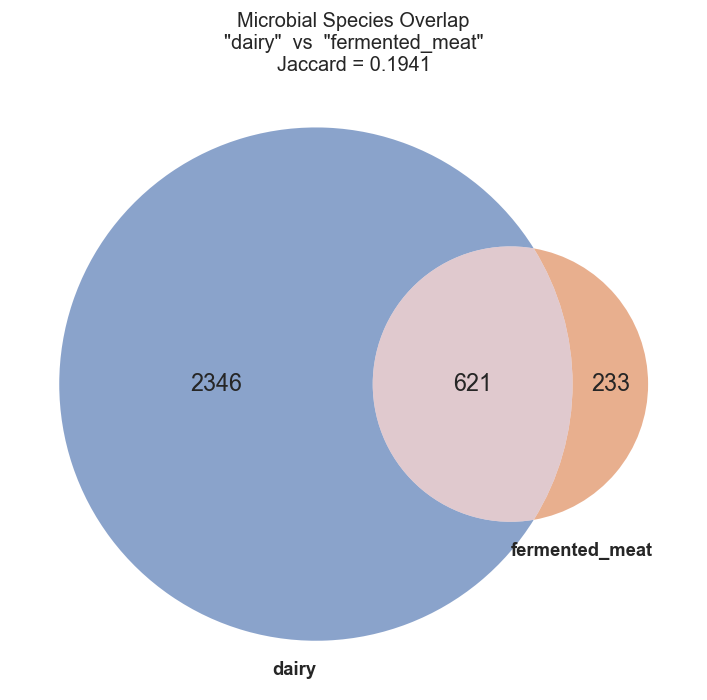

Plot saved → venn_species_overlap.png


In [17]:
try:
    from matplotlib_venn import venn2
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'matplotlib-venn', '-q'])
    from matplotlib_venn import venn2

cat1, cat2 = richness.head(2)['category'].tolist()
print(f"Comparing: '{cat1}'  vs  '{cat2}'")

sp1    = set(merged_filtered.loc[merged_filtered['category'] == cat1, '#taxonomy'].unique())
sp2    = set(merged_filtered.loc[merged_filtered['category'] == cat2, '#taxonomy'].unique())
shared = sp1 & sp2
union  = sp1 | sp2

print(f"\nSpecies unique to '{cat1}'  : {len(sp1 - sp2):,}")
print(f"Species unique to '{cat2}'  : {len(sp2 - sp1):,}")
print(f"Shared species              : {len(shared):,}")
print(f"Jaccard similarity index    : {len(shared) / len(union):.4f}")

if shared:
    print(f'\nTop shared species (last taxonomic level):')
    for s in sorted(shared)[:20]:  # show first 20
        sep   = '|' if '|' in s else ';'
        label = s.split(sep)[-1].strip()
        print(f'  {label}')
    if len(shared) > 20:
        print(f'  ... and {len(shared) - 20} more')

# ── Venn diagram ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
v = venn2(
    subsets=[sp1, sp2],
    set_labels=(cat1, cat2),
    ax=ax,
    set_colors=('#4C72B0', '#DD8452'),
    alpha=0.65
)
for region_id in ('10', '01', '11'):
    lbl = v.get_label_by_id(region_id)
    if lbl:
        lbl.set_fontsize(14)
for set_lbl in v.set_labels:
    if set_lbl:
        set_lbl.set_fontsize(11)
        set_lbl.set_fontweight('bold')

ax.set_title(
    f'Microbial Species Overlap\n"{cat1}"  vs  "{cat2}"\nJaccard = {len(shared)/len(union):.4f}',
    fontsize=12
)
plt.tight_layout()
plt.savefig('venn_species_overlap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → venn_species_overlap.png')